# 04 Modelo Regresion Total Pedido

Este notebook usa la base `EDA`, entrena una `Regresion Lineal`, estima el total del pedido y exporta el `Parquet` final de la etapa `04`.


## 1. Librerias


In [1]:
# Manejo de rutas internas del proyecto.
from pathlib import Path
# Guardado de listas de variables en formato JSON.
import json

# Persistencia del modelo entrenado.
import joblib
# Operaciones numericas de apoyo para metricas y residuos.
import numpy as np
# Manejo tabular de la base de regresion.
import pandas as pd
# Graficas generales del modelo.
import matplotlib.pyplot as plt
# Visualizaciones estadisticas para dispersion y residuos.
import seaborn as sns
# Preprocesamiento por tipo de columna.
from sklearn.compose import ColumnTransformer
# Relleno de valores faltantes si se llegaran a presentar.
from sklearn.impute import SimpleImputer
# Modelo de regresion elegido para estimar el total del pedido.
from sklearn.linear_model import LinearRegression
# Metricas principales de error y ajuste del modelo.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Particion de entrenamiento y prueba.
from sklearn.model_selection import train_test_split
# Construccion del flujo completo de transformacion y modelo.
from sklearn.pipeline import Pipeline
# Codificacion de variables categoricas y escalamiento numerico.
from sklearn.preprocessing import OneHotEncoder, StandardScaler


### Para que se usan estas librerias

- `Path`: localizar la raiz del proyecto y construir rutas de entrada, salida y guardado del modelo.
- `json`: guardar la lista final de variables utilizadas por el modelo.
- `joblib`: exportar el modelo ya entrenado para reutilizarlo.
- `numpy` y `pandas`: preparar la base, calcular residuos y construir tablas de metricas.
- `matplotlib` y `seaborn`: generar visualizaciones de apoyo para revisar el comportamiento de la regresion.
- `ColumnTransformer`, `Pipeline`, `OneHotEncoder`, `StandardScaler` y `SimpleImputer`: preparar las variables antes del entrenamiento.
- `LinearRegression`: entrenar el modelo de regresion para estimar `total_pedido`.
- metricas de `sklearn`: medir error absoluto, error cuadratico y capacidad de ajuste.


## 2. Definir rutas


### Nota sobre nombres tecnicos

En el codigo y en las columnas tecnicas se usa `anio` en lugar de `año`. La letra `ñ` se deja solo en el texto explicativo, pero no en nombres de variables, columnas o archivos para evitar caracteres especiales y mantener compatibilidad.


In [2]:
from pathlib import Path

def resolve_project_root() -> Path:
    # Buscar la raiz del proyecto a partir del directorio actual.
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "README.md").exists() and (candidate / "parquets").exists():
            return candidate
    raise FileNotFoundError("No se pudo localizar la raiz del proyecto")

PROJECT_ROOT = resolve_project_root()

# Definir las rutas de entrada y salida de la etapa 04.
INPUT_PATH = PROJECT_ROOT / "parquets" / "02_EDA_Base_Tickets" / "02_base_eda_tickets.parquet"
OUTPUT_DIR = PROJECT_ROOT / "parquets" / "04_Modelo_Regresion_Total_Pedido"
OUTPUT_PATH = OUTPUT_DIR / "04_tickets_regresion.parquet"
MODEL_DIR = PROJECT_ROOT / "models" / "04_Modelo_Regresion_Total_Pedido"
MODEL_PATH = MODEL_DIR / "04_modelo_regresion_lineal.joblib"
FEATURES_PATH = MODEL_DIR / "04_features_regresion_lineal.json"

print(f"Raiz del proyecto: {PROJECT_ROOT}")
print(f"Parquet de entrada: {INPUT_PATH}")
print(f"Parquet de salida: {OUTPUT_PATH}")
print(f"Modelo entrenado: {MODEL_PATH}")


Raiz del proyecto: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning
Parquet de entrada: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\parquets\02_EDA_Base_Tickets\02_base_eda_tickets.parquet
Parquet de salida: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\parquets\04_Modelo_Regresion_Total_Pedido\04_tickets_regresion.parquet
Modelo entrenado: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\models\04_Modelo_Regresion_Total_Pedido\04_modelo_regresion_lineal.joblib


## 3. Cargar la base EDA


In [3]:
# Leer la base EDA de entrada.
df = pd.read_parquet(INPUT_PATH)

# Mostrar las primeras filas de la base para regresion.
df.head()


,id_ticket_modelado,fecha,anio_mes,dia,mes,nombre_mes,trimestre,anio,dia_semana,dia_tipo,...,residuo_abs_subtotal_total,residuo_pago_total,ticket_consistente_subtotal,ticket_consistente_pago,incluye_bebida,incluye_postre,incluye_entrada,incluye_platillo_fuerte,ticket_alto,rango_total_pedido
0,1,2024-01-02,2024-01,2,1,Enero,1,2024,Martes,Entre semana,...,695.0,0.0,0,1,0,0,0,1,0,Bajo
1,2,2024-01-03,2024-01,3,1,Enero,1,2024,Miércoles,Entre semana,...,3580.0,0.0,0,1,1,1,1,1,0,Bajo
2,3,2024-01-03,2024-01,3,1,Enero,1,2024,Miércoles,Entre semana,...,4750.0,0.0,0,1,1,1,1,1,0,Medio
3,4,2024-01-03,2024-01,3,1,Enero,1,2024,Miércoles,Entre semana,...,1115.0,-65.0,0,0,1,0,0,1,0,Medio
4,5,2024-01-03,2024-01,3,1,Enero,1,2024,Miércoles,Entre semana,...,125.0,0.0,0,1,0,0,0,1,0,Medio


### Resultado

La base `EDA` se cargo correctamente desde `02_base_eda_tickets.parquet`.

La vista previa muestra `5 filas x 43 columnas`, lo que confirma que la etapa de regresion parte de una base ya enriquecida con variables exploratorias.

En esta etapa ya se observan campos utiles para estimar `total_pedido`, como:

- `anio_mes`
- `dia_tipo`
- `residuo_pago_total`
- `ticket_consistente_pago`
- `rango_total_pedido`
- `total_pedido`

En los nombres tecnicos se mantiene `anio` sin `ñ` por compatibilidad con columnas, archivos y artefactos del modelo.


## 4. Seleccionar variables y target


In [4]:
# Definir las variables explicativas del modelo.
# Se combinan variables de calendario, sucursal, empleado, mesa, pago y composicion del ticket.
# Los nombres tecnicos se mantienen sin acentos ni ñ para conservar compatibilidad.
FEATURES = [
    "dia", "mes", "trimestre", "dia_semana", "dia_tipo", "fin_semana",
    "ciudad", "capacidad_sucursal", "tipo_empleado", "salario", "turno",
    "numero_mesa", "capacidad_mesa", "metodo_pago", "lineas_ticket",
    "cantidad_total", "platillos_distintos", "categorias_distintas",
    "incluye_bebida", "incluye_postre", "incluye_entrada", "incluye_platillo_fuerte"
]

# Definir la variable objetivo.
TARGET = "total_pedido"

# Separar la matriz de entrada y la serie objetivo para el entrenamiento.
X = df[FEATURES].copy()
y = df[TARGET].copy()
X.head()


,dia,mes,trimestre,dia_semana,dia_tipo,fin_semana,ciudad,capacidad_sucursal,tipo_empleado,salario,...,capacidad_mesa,metodo_pago,lineas_ticket,cantidad_total,platillos_distintos,categorias_distintas,incluye_bebida,incluye_postre,incluye_entrada,incluye_platillo_fuerte
0,2,1,1,Martes,Entre semana,False,León,120,Auxiliar de cocina,7500.0,...,6,Efectivo,4,5,4,3,0,0,0,1
1,3,1,1,Miércoles,Entre semana,False,León,120,Mesero,8500.0,...,2,Efectivo,21,39,19,10,1,1,1,1
2,3,1,1,Miércoles,Entre semana,False,León,120,Mesero,8500.0,...,4,Tarjeta de crédito,26,51,19,10,1,1,1,1
3,3,1,1,Miércoles,Entre semana,False,León,120,Auxiliar de cocina,7500.0,...,6,Efectivo,7,11,7,5,1,0,0,1
4,3,1,1,Miércoles,Entre semana,False,Guanajuato,75,Hostess,8000.0,...,6,Efectivo,1,1,1,1,0,0,0,1


## 5. Particion de entrenamiento y prueba


In [5]:
# Dividir la base en entrenamiento y prueba.
# En regresion no se usa estratificacion porque la variable objetivo es continua.
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

# Revisar dimensiones de las particiones.
X_train.shape, X_test.shape


((933, 22), (234, 22))

## 6. Entrenar y evaluar el modelo


In [6]:
# Separar columnas numericas y categoricas.
numericas = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categoricas = X.select_dtypes(include=["object"]).columns.tolist()

# Definir el preprocesador del pipeline.
# Las numericas se imputan con mediana y se escalan; las categoricas se imputan y codifican.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numericas,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categoricas,
        ),
    ]
)

# Definir el pipeline completo de regresion.
# Se usa regresion lineal como primera aproximacion para estimar un monto continuo.
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])

# Entrenar el modelo con la muestra de entrenamiento.
pipeline.fit(X_train, y_train)

# Generar predicciones sobre test.
y_pred = pipeline.predict(X_test)

# Resumir metricas principales del modelo.
metricas = pd.DataFrame(
    {
        "metrica": ["mae", "rmse", "r2"],
        "valor": [
            round(float(mean_absolute_error(y_test, y_pred)), 4),
            round(float(np.sqrt(mean_squared_error(y_test, y_pred))), 4),
            round(float(r2_score(y_test, y_pred)), 4),
        ],
    }
)
metricas


,metrica,valor
0,mae,92.3532
1,rmse,111.6319
2,r2,0.2364


### Resultado

La seleccion de variables deja una matriz de entrada con `22 columnas` para el modelo.

La vista previa de `X` muestra `5 filas x 22 columnas`, lo que confirma que la etapa de regresion ya trabaja solo con las variables seleccionadas para estimar `total_pedido`.

La particion de entrenamiento y prueba quedo asi:

- `X_train = (933, 22)`
- `X_test = (234, 22)`

Las metricas obtenidas en prueba fueron:

- `mae = 92.3532`
- `rmse = 111.6319`
- `r2 = 0.2364`

Esto indica que el modelo si capta parte de la variacion del monto, aunque todavia queda un margen de error considerable y el ajuste general es moderado.


## 7. Visualizaciones del modelo


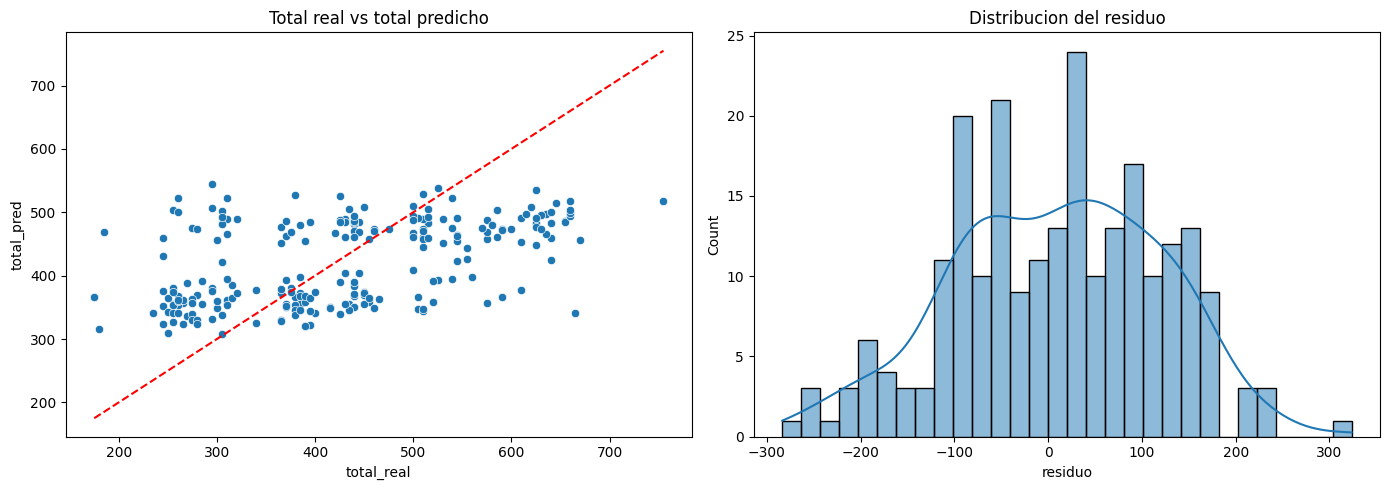

In [7]:
# Construir una vista rapida de resultados sobre test.
resultados_test = X_test.copy()
resultados_test["total_real"] = y_test
resultados_test["total_pred"] = y_pred
resultados_test["residuo"] = resultados_test["total_real"] - resultados_test["total_pred"]

# Graficar comparacion entre total real y total predicho.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=resultados_test, x="total_real", y="total_pred", ax=axes[0])
# Dibujar una linea de referencia ideal donde prediccion = valor real.
min_val = min(resultados_test["total_real"].min(), resultados_test["total_pred"].min())
max_val = max(resultados_test["total_real"].max(), resultados_test["total_pred"].max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--")
axes[0].set_title("Total real vs total predicho")
axes[0].set_xlabel("total_real")
axes[0].set_ylabel("total_pred")

# Graficar la distribucion del residuo.
sns.histplot(resultados_test["residuo"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribucion del residuo")
axes[1].set_xlabel("residuo")
plt.tight_layout()


### Resultado

Las visualizaciones permiten revisar el comportamiento del modelo de regresion sobre el conjunto de prueba.

En la grafica `total_real` vs `total_pred` se observa que el modelo sigue una tendencia general, pero varios puntos quedan alejados de la linea ideal, lo cual es consistente con un `r2 = 0.2364`.

La distribucion del residuo se concentra alrededor de `0`, aunque tambien presenta dispersion hacia errores positivos y negativos, lo que confirma que la prediccion todavia tiene variabilidad relevante en algunos tickets.


## 8. Exportar el parquet final del modelo


In [8]:
# Crear carpetas de salida para la etapa 04.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Entrenar el modelo final con toda la base disponible.
# Aqui ya no se usa solo la particion de entrenamiento, sino la base completa de la etapa 02.
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])
final_pipeline.fit(X, y)

# Generar la salida final con predicciones y errores por ticket.
df_predictions = df.copy()
df_predictions["pred_total_pedido"] = final_pipeline.predict(X)
df_predictions["residuo_total_pedido"] = df_predictions["total_pedido"] - df_predictions["pred_total_pedido"]
df_predictions["error_abs_total_pedido"] = df_predictions["residuo_total_pedido"].abs()
df_predictions["modelo"] = "Regresion Lineal"
df_predictions["fuente_parquet"] = "02_base_eda_tickets.parquet"
df_predictions["conjunto_evaluacion"] = "train"
df_predictions.loc[idx_test, "conjunto_evaluacion"] = "test"

# Unir a la salida final las predicciones observadas sobre test para poder revisarlas despues.
test_lookup = pd.DataFrame(
    {
        "idx": idx_test,
        "pred_total_pedido_test": y_pred,
        "residuo_total_pedido_test": y_test.to_numpy() - y_pred,
    }
).set_index("idx")

df_predictions = df_predictions.join(test_lookup, how="left")

# Exportar el parquet final y los artefactos tecnicos del modelo.
df_predictions.to_parquet(OUTPUT_PATH, index=False)
joblib.dump(final_pipeline, MODEL_PATH)
FEATURES_PATH.write_text(json.dumps(FEATURES, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Parquet generado en: {OUTPUT_PATH}")
print(f"Modelo guardado en: {MODEL_PATH}")


Parquet generado en: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\parquets\04_Modelo_Regresion_Total_Pedido\04_tickets_regresion.parquet
Modelo guardado en: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\models\04_Modelo_Regresion_Total_Pedido\04_modelo_regresion_lineal.joblib


In [9]:
# Verificar la salida exportada de la etapa 04.
df_exportado = pd.read_parquet(OUTPUT_PATH)
df_exportado.shape


(1167, 51)

### Resultado

El parquet final de regresion se genero correctamente en la carpeta `parquets/04_Modelo_Regresion_Total_Pedido`.

Tambien se guardo el modelo entrenado en la carpeta `models/04_Modelo_Regresion_Total_Pedido`.

Despues de volver a leer la salida exportada, se confirmo que el archivo final conserva una estructura de:

- `1167 filas`
- `51 columnas`

La salida final incluye, entre otras columnas nuevas, `pred_total_pedido`, `residuo_total_pedido`, `error_abs_total_pedido`, `modelo`, `fuente_parquet` y `conjunto_evaluacion`.

Con esto, la etapa `04` queda cerrada con una salida que ya incluye el valor estimado, el residuo y el error absoluto por ticket.


## Conclusi?n

La etapa `04` entrena una regresion lineal para estimar `total_pedido` y genera `04_tickets_regresion.parquet` con `1167 filas` y `51 columnas`. El resultado final deja disponibles la prediccion, el residuo y el error absoluto por ticket para su analisis posterior.
